# OpenCV Experiments
### Computer Vision Fellowship 2026

Prepared by:
Muhammad Abdullah Nazir

BS Artificial Intelligence

**AI Summer Internship 2026 | Track 1: Computer Vision | Assignment 4**

---

## What is this notebook?
This notebook contains **5 hands-on computer vision experiments** using OpenCV.
Each experiment teaches you a core concept, shows you working code, and produces
visual output so you can see exactly what the algorithm is doing.

---
## 🔧 Setup — Run This First!

This cell imports all the libraries we need and sets up display settings.
**Always run this cell before anything else.**


In [5]:
# ─── Import Libraries ────────────────────────────────────────────────────
import cv2                        # OpenCV — our main computer vision library
import numpy as np                # NumPy — for working with image arrays
import matplotlib.pyplot as plt   # Matplotlib — for displaying images & plots
import matplotlib.patches as patches

---
# 🧪 Experiment 1 — Color Space Conversion

## What is a Color Space?
A **color space** is a way of representing color using numbers.
The same pixel of color can be described in many different ways,
depending on which color space you use.

Think of it like temperature — 100°C and 212°F are the same temperature,
just described in different units. Similarly, one pixel color can be
described as RGB, or as HSV, or as LAB — all describing the same color.

## Why Does This Matter in Computer Vision?
Different color spaces make different tasks **easier**:

| Color Space | What It Separates | Best Used For |
|---|---|---|
| **BGR** | Blue, Green, Red | OpenCV's default format |
| **RGB** | Red, Green, Blue | Display (matplotlib, PIL) |
| **Grayscale** | Just brightness | Edge detection, thresholding |
| **HSV** | Hue, Saturation, Value | Detecting objects by color |
| **LAB** | Lightness, A channel, B channel | Color correction, comparison |
| **YCrCb** | Brightness + color difference | Skin detection, video compression |

## Key Insight: Why HSV is Special
In BGR/RGB, a red apple in bright sunlight vs. a red apple in shadow
will have **very different** pixel values — even though they're both 'red'.

In **HSV**, the **Hue channel** captures just the color (e.g. red = 0°),
while **Value** captures the brightness separately.
So detecting 'red objects' becomes as simple as checking if Hue ≈ 0.


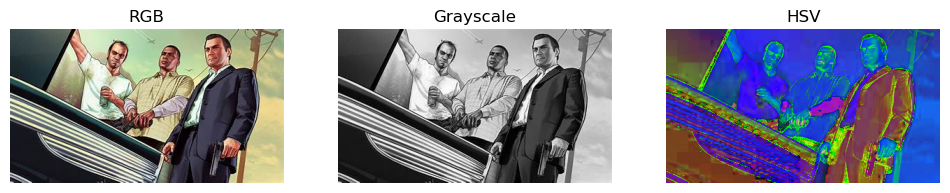

In [7]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("sample.jpg")

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray,cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

---
# 🧪 Experiment 2 — Image Filtering

## What is Image Filtering?
Filtering modifies an image by replacing each pixel's value with
a combination of its neighboring pixels.

This is done using a **kernel** (also called a filter or mask) —
a small grid of numbers that slides across the image.

## How it Works (Convolution)
```
For each pixel in the image:
  1. Place the kernel centered on that pixel
  2. Multiply each kernel value by the corresponding pixel
  3. Sum all the results
  4. That sum becomes the new pixel value
```

## Types of Filters

| Filter | Effect | Best For |
|---|---|---|
| **Box Blur** | Average of neighbors (equal weights) | Simple smoothing |
| **Gaussian Blur** | Weighted average (center weighted) | Noise reduction |
| **Median Blur** | Median value of neighbors | Salt-and-pepper noise |
| **Bilateral** | Blurs but preserves edges | Portrait smoothing |
| **Sharpen** | Enhances details | Making blurry images clearer |
| **Laplacian** | Second-order derivative | Detecting blobs/edges |

## Why Blur at All?
Raw camera images always contain **noise** — random pixel variations
caused by sensor imperfections, low light, heat, etc.
Blurring reduces this noise so later operations (like edge detection) work better.


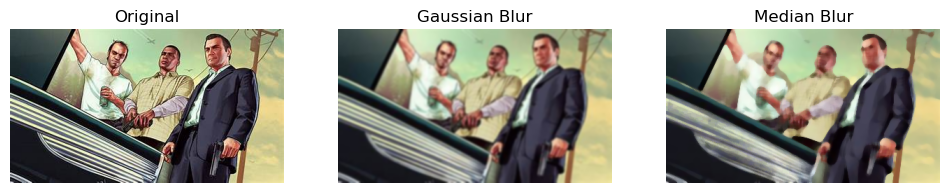

In [9]:
gaussian = cv2.GaussianBlur(image,(7,7),0)

median = cv2.medianBlur(image,7)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(gaussian,cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(median,cv2.COLOR_BGR2RGB))
plt.title("Median Blur")
plt.axis("off")

plt.show()

---
# 🧪 Experiment 3 — Edge Detection

## What is an Edge?
An **edge** is a location in an image where the pixel intensity
changes sharply — usually because two different objects or regions
are next to each other.

Edges correspond to object boundaries, making edge detection one
of the most fundamental operations in computer vision.

## The Canny Edge Detection Algorithm
Developed by John F. Canny in 1986, it is still the most widely
used edge detector today. It works in 5 steps:

```
Step 1: Gaussian Blur          Remove noise (noise looks like tiny edges)
        ↓
Step 2: Sobel Gradient         Find intensity changes in X and Y direction
        ↓                      Gx = horizontal change, Gy = vertical change
Step 3: Gradient Magnitude     M = √(Gx² + Gy²)   Direction = arctan(Gy/Gx)
        ↓
Step 4: Non-Max Suppression    Thin edges to exactly 1 pixel wide
        ↓
Step 5: Hysteresis Threshold   Keep strong edges; keep weak edges only if
                               they connect to a strong edge
```

## The Two Threshold Parameters
- **Low threshold**: below this → definitely not an edge
- **High threshold**: above this → definitely an edge
- **Between the two**: edge only if it touches a strong edge


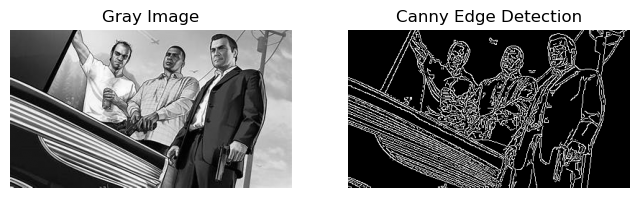

In [11]:
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,100,200)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gray,cmap="gray")
plt.title("Gray Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges,cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

---
# 🧪 Experiment 4 — Contour Detection

## What is a Contour?
A **contour** is a curve that joins all continuous points along a
boundary where the color or intensity is the same.

In simpler terms: contours are the **outlines** of objects in an image.

Think of a contour like the outline you'd draw if you traced around
an object with a pen — following the exact shape of its boundary.

## How OpenCV Finds Contours
```
Original Image
    ↓
Grayscale (remove color, keep brightness)
    ↓
Threshold (make image pure black and white)
    ↓
findContours() (trace outlines of white regions)
    ↓
List of contour points (x,y coordinates)
```

## What You Can Measure from a Contour
Once you have a contour, you can extract lots of useful data:

| Measurement | OpenCV Function | What it tells you |
|---|---|---|
| **Area** | `cv2.contourArea(c)` | How many pixels inside |
| **Perimeter** | `cv2.arcLength(c, True)` | Length of the boundary |
| **Bounding Box** | `cv2.boundingRect(c)` | Enclosing rectangle |
| **Centroid** | `cv2.moments(c)` | Center point of the shape |
| **Min Circle** | `cv2.minEnclosingCircle(c)` | Smallest circle that fits |
| **Convex Hull** | `cv2.convexHull(c)` | Outermost convex boundary |


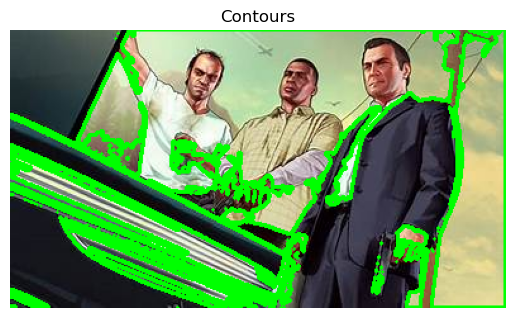

In [13]:
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image.copy()

cv2.drawContours(output,contours,-1,(0,255,0),2)

plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.title("Contours")
plt.axis("off")
plt.show()

---
# 🧪 Experiment 5 — Shape Detection

## What is Shape Detection?
Shape detection goes one step further than contour detection.
Instead of just finding outlines, we **classify** each shape —
telling whether it is a triangle, rectangle, circle, etc.

## How to Classify Shapes
The key technique is **polygon approximation** using the
**Douglas-Peucker algorithm** (`cv2.approxPolyDP`).

This simplifies a contour into a polygon with fewer points,
then we classify by counting the number of vertices (corners):

```
Number of Vertices → Shape
───────────────────────────
       3            Triangle
       4            Rectangle or Square
       5            Pentagon
       6            Hexagon
      7+            Circle (many-sided polygon ≈ circle)
```

## Epsilon Parameter
```
epsilon = accuracy × perimeter
```
- **Small epsilon** → polygon stays close to original (more vertices)
- **Large epsilon** → polygon is simplified more (fewer vertices)
- Typical value: `epsilon = 0.03 × perimeter`

## Detecting Circles Separately
Circles have too many vertices for polygon approximation.
We detect them using the **circularity formula**:
```
Circularity = (4 × π × Area) / Perimeter²

Perfect circle   → Circularity = 1.0
Rough circle     → Circularity > 0.8
Square           → Circularity ≈ 0.785
Very irregular   → Circularity close to 0
```


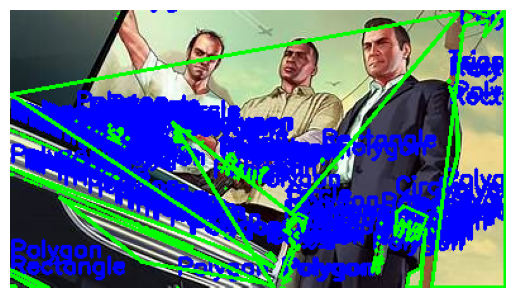

In [15]:
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

contours,_ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image.copy()

for contour in contours:

    approx = cv2.approxPolyDP(
        contour,
        0.02*cv2.arcLength(contour,True),
        True
    )

    sides = len(approx)

    if sides==3:
        shape="Triangle"

    elif sides==4:
        shape="Rectangle"

    elif sides>7:
        shape="Circle"

    else:
        shape="Polygon"

    x,y,w,h = cv2.boundingRect(approx)

    cv2.putText(output,
                shape,
                (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2)

    cv2.drawContours(output,[approx],0,(0,255,0),2)

plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

---
# 📋 Summary — What We Learned

| Experiment | Core Function | What It Does | Key Takeaway |
|---|---|---|---|
| **1. Color Space** | `cv2.cvtColor()` | Converts between BGR, Gray, HSV, LAB | HSV separates color from brightness — best for color-based detection |
| **2. Filtering** | `cv2.GaussianBlur()` / `cv2.medianBlur()` | Smooths image, removes noise | Median beats Gaussian for salt-and-pepper noise; always blur before edge detection |
| **3. Edge Detection** | `cv2.Canny()` | Finds boundaries between regions | Low/High thresholds control sensitivity; too low = noise, too high = missed edges |
| **4. Contours** | `cv2.findContours()` | Traces object outlines | From contours you get area, perimeter, centroid, bounding box |
| **5. Shape Detection** | `cv2.approxPolyDP()` | Classifies shape by vertex count | 3=triangle, 4=rect, 5=pentagon, 6=hexagon, high circularity=circle |